In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [6]:
import warnings 
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

In [7]:
df = pd.read_csv('../dataset/AIML Dataset.csv')

In [8]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [10]:
df['isFraud'].value_counts()


isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [11]:
df['isFlaggedFraud'].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [12]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [13]:
df.shape

(6362620, 11)

In [14]:
df['isFraud'].value_counts()[1]/df.shape[0]*100 

np.float64(0.12908204481801522)

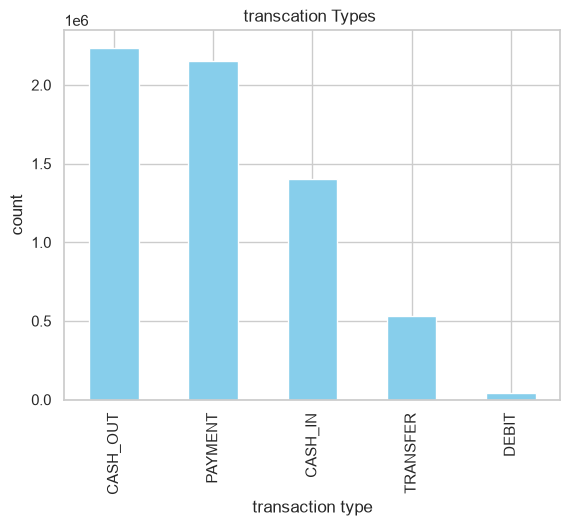

In [15]:
df["type"].value_counts().plot(kind="bar",title="transcation Types ", color = 'skyblue')
plt.xlabel("transaction type")
plt.ylabel('count')
plt.show()

In [16]:
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)

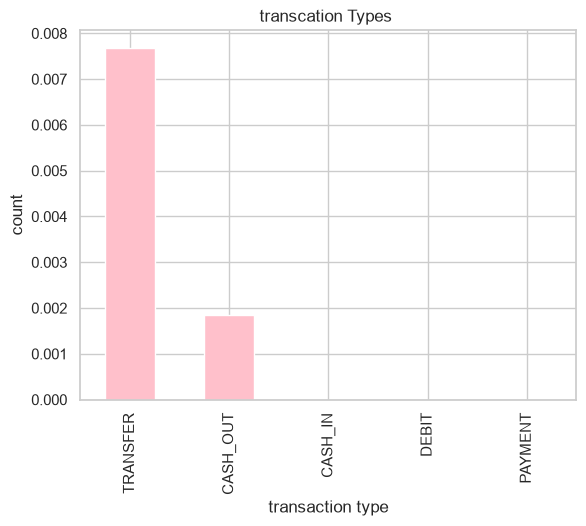

In [17]:
fraud_by_type.plot(kind="bar",title="transcation Types ", color = 'pink')
plt.xlabel("transaction type")
plt.ylabel('count')
plt.show()

In [18]:
df['amount'].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

Text(0.5, 1.0, 'Transaction amount distribution (log scaled)')

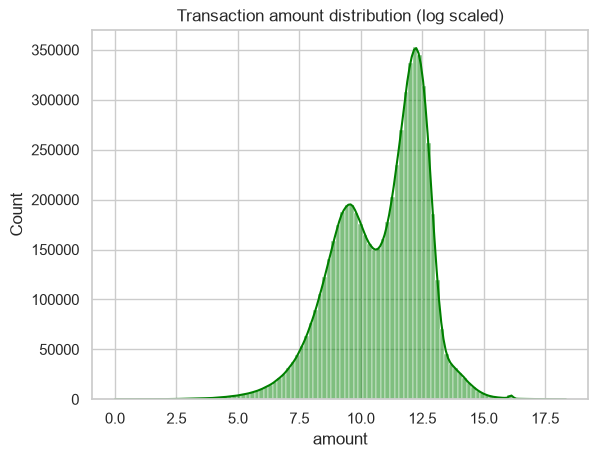

In [19]:
sns.histplot(np.log1p(df['amount']),bins= 100 ,kde =True , color ='green')
plt.title("Transaction amount distribution (log scaled)")

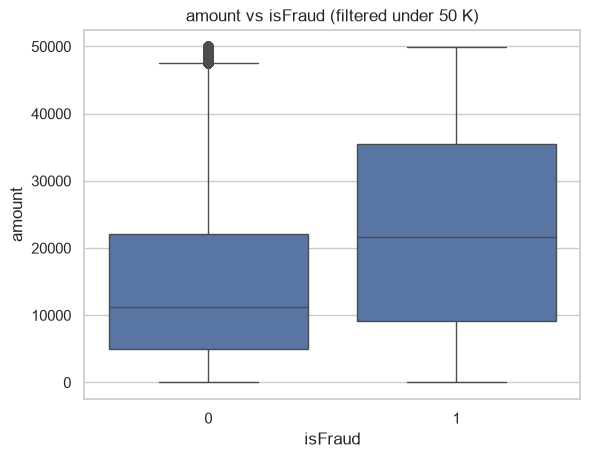

In [20]:
sns.boxplot(data = df[df['amount']<50000 ], x= "isFraud", y= "amount")
plt.title("amount vs isFraud (filtered under 50 K)")
plt.show()

In [21]:
df['balanceDiffOrig'] = df['oldbalanceOrg']- df['newbalanceOrig']
df['balanceDiffDest'] = df['oldbalanceDest']- df['newbalanceDest']



In [22]:
(df["balanceDiffOrig"]<0).sum()


np.int64(1399253)

In [23]:
(df["balanceDiffDest"]<0).sum()

np.int64(2806464)

In [24]:
df.head(2)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0


In [25]:
# frauds_per_step = df[ df["isFraud"]==1]["step"].value_counts().sort_index()
# plt.plot(frauds_per_step.index, frauds_per_step.values,labels= "Fraud per step")
# plt.xlabel("step (time)")
# plt.ylabel("Number of Frauds")
# plt.title("Fraud over time")
# plt.grid(True)
# plt.show()

In [26]:
df.drop(columns="step", inplace = True)

In [27]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [28]:
top_senders = df["nameOrig"].value_counts().head(10)

In [29]:
top_senders

nameOrig
C2098525306    3
C400299098     3
C1999539787    3
C1065307291    3
C545315117     3
C1976208114    3
C1784010646    3
C1530544995    3
C1902386530    3
C1677795071    3
Name: count, dtype: int64

In [30]:
top_recievers = df['nameDest'].value_counts()

In [31]:
top_recievers

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
              ... 
C1812552860      1
C1470998563      1
C1850423904      1
C1881841831      1
C2080388513      1
Name: count, Length: 2722362, dtype: int64

In [32]:
fraud_user= df[df['isFraud']==1]['nameOrig'].value_counts().head(10)

In [33]:
fraud_user

nameOrig
C1305486145    1
C840083671     1
C1420196421    1
C2101527076    1
C137533655     1
C1118430673    1
C749981943     1
C1334405552    1
C467632528     1
C1364127192    1
Name: count, dtype: int64

In [34]:
fraud_types = df[df["type"].isin(["TRANSFER","CASH_OUT"])]

In [35]:
fraud_types["type"].value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

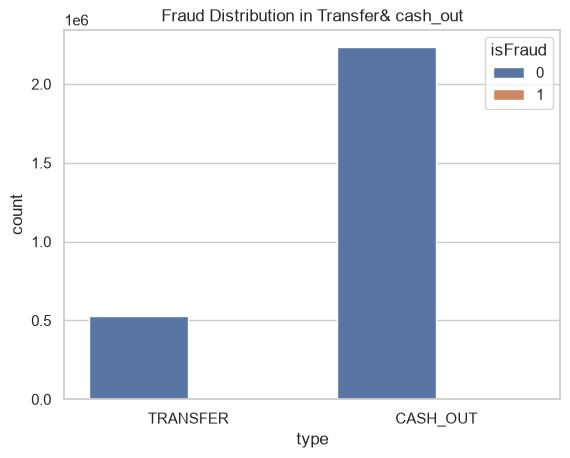

In [36]:
sns.countplot(data= fraud_types, x ="type" , hue ="isFraud")
plt.title("Fraud Distribution in Transfer& cash_out")
plt.show()

In [37]:
numeric_val = df.select_dtypes('number')

In [38]:
correlation = numeric_val.corr()

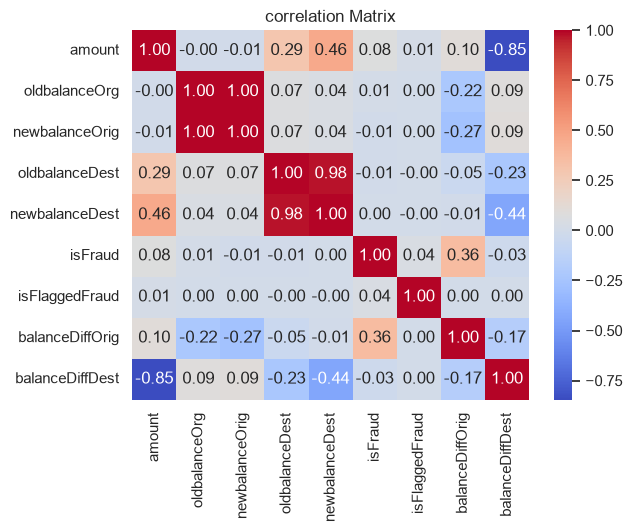

In [39]:
sns.heatmap(correlation,annot=True,cmap = "coolwarm", fmt = ".2f")
plt.title("correlation Matrix")
plt.show()

In [40]:
zero_after_transfer = df[
    (df["oldbalanceOrg"]>0 ) &
    (df["newbalanceOrig"] ==0 ) &
    (df["type"].isin(["TRANSFER","CASH_OUT"]) )
]

In [41]:
len(zero_after_transfer)

1188074

In [42]:
zero_after_transfer.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,-46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,-2712905.89


In [43]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder





In [45]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [46]:
df_model= df.drop(["nameOrig","nameDest","isFlaggedFraud"],axis=1)

In [ ]:
# df_model = df_model.sample(1000000,random_state=42)

In [48]:
df_model.head(
    
)

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0


In [49]:
df_model.shape


(6362620, 9)

In [50]:
categorical = ["type"]
numeric = ["amount" , "oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest"]

In [51]:
y= df_model["isFraud"]
X= df_model.drop("isFraud",axis = 1)

In [52]:
X_train ,X_test , y_train , y_test= train_test_split(X,y,test_size=0.3,stratify=y)

In [53]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric),
        ("cat" ,OneHotEncoder(drop = "first"),categorical)
    ],
    remainder= "drop"
)

In [54]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [55]:
# models = {
#     "Logistic Regression": LogisticRegression(
#         class_weight="balanced",
#         max_iter=1000
#     ),

#     "Decision Tree": DecisionTreeClassifier(
#         random_state=42
#     ),

#     "Random Forest": RandomForestClassifier(
#         n_estimators=200,
#         class_weight="balanced",
#         random_state=42
#     ),
#     "Gradient Boosting": GradientBoostingClassifier(
#         random_state=42
#     ),

#     "XGBoost": XGBClassifier(
#         random_state=42,
#         eval_metric="logloss"
#     )
#     }

In [56]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [ ]:
# from sklearn.pipeline import Pipeline
# from sklearn.metrics import (
#     precision_score,
#     recall_score,
#     f1_score,
#     classification_report,
#     confusion_matrix
# )

# results = []

# for name, model in models.items():

#     pipe = Pipeline([
#         ("prep", preprocessor),
#         ("model", model)
#     ])

#     pipe.fit(X_train, y_train)

#     y_pred = pipe.predict(X_test)

#     precision = precision_score(y_test, y_pred)
#     recall = recall_score(y_test, y_pred)
#     f1 = f1_score(y_test, y_pred)

#     results.append([
#         name,
#         precision,
#         recall,
#         f1
#     ])

#     print(f"\n{'='*60}")
#     print(f"MODEL: {name}")
#     print(f"{'='*60}")

#     print("\nClassification Report:")
#     print(classification_report(y_test, y_pred))

#     print("\nConfusion Matrix:")
#     print(confusion_matrix(y_test, y_pred))

# results_df = pd.DataFrame(
#     results,
#     columns=[
#         "Model",
#         "Precision",
#         "Recall",
#         "F1"
#     ]
# )

# print("\nModel Comparison")
# print(results_df.sort_values("F1", ascending=False))

In [58]:
pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42
    ))
])

In [59]:
pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['type','amount','oldbalanceOrg',...,'newbalanceDest','balanceDiffOrig', 'balanceDiffDest']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthroug

In [60]:
y_pred = pipeline.predict(X_test)

In [61]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.88      0.86      0.87      2464

    accuracy                           1.00   1908786
   macro avg       0.94      0.93      0.94   1908786
weighted avg       1.00      1.00      1.00   1908786



In [62]:
pipeline.score(X_test,y_test)*100


99.96725667518517

In [63]:
import joblib

In [65]:
import joblib

joblib.dump(
    pipeline,
    "../models/fraud_model.pkl"
)

['../models/fraud_model.pkl']

In [66]:
model = joblib.load(
    "../models/fraud_model.pkl"
)

In [67]:
print(type(model))

<class 'sklearn.pipeline.Pipeline'>


In [68]:
predictions = model.predict(X_test)

print(predictions[:10])

[0 0 0 0 0 0 0 0 0 0]


In [84]:
import pandas as pd

sample = pd.DataFrame({
    "type": ["TRANSFER"],
    "amount": [700000],
    "oldbalanceOrg": [50000],
    "newbalanceOrig": [0],
    "oldbalanceDest": [230],
    "newbalanceDest": [500],
    "balanceDiffOrig": [9000],
    "balanceDiffDest": [0]
})

prediction = model.predict(sample)

print(prediction)

[0]


In [85]:
probability = model.predict_proba(sample)

print(probability)

[[0.995 0.005]]


In [86]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [88]:
fraud_df=df[df["isFraud"]==1]


In [89]:
fraud_df

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.00,0.00,1,0,181.00,0.00
3,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.00,0.00,1,0,181.00,21182.00
251,TRANSFER,2806.00,C1420196421,2806.00,0.0,C972765878,0.00,0.00,1,0,2806.00,0.00
252,CASH_OUT,2806.00,C2101527076,2806.00,0.0,C1007251739,26202.00,0.00,1,0,2806.00,26202.00
680,TRANSFER,20128.00,C137533655,20128.00,0.0,C1848415041,0.00,0.00,1,0,20128.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0,339682.13,-339682.13
6362616,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0,6311409.28,0.00
6362617,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0,6311409.28,-6311409.27
6362618,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0,850002.52,0.00


array([1.87416402e-01, 3.39054524e-01, 1.95845230e-01, 4.58300898e-02,
       5.31608762e-02, 4.25808574e-02, 2.52084941e-04, 5.42500515e-02,
       8.16098854e-02])